# EDA — understanding the catalog the recommender serves

Before building a recommender, two things have to be understood from the data alone: **the catalog** it recommends over, and **the baseline** it has to beat. This dataset is a static product catalog with **no user-interaction data**, so everything here is content-side — which is exactly why revenue and engagement stay *motivation* and the measured metrics are content-based (see [`docs/requirement.md`](../docs/requirement.md)).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.recommender import load_catalog, relevant_mask

df = load_catalog()
f"{len(df):,} products | {df.subCategory.nunique()} subCategories | "
f"{df.articleType.nunique()} articleTypes"

'115 articleTypes'

In [2]:
df[['productDisplayName', 'subCategory', 'articleType', 'gender', 'baseColour']].head()

,productDisplayName,subCategory,articleType,gender,baseColour
0,Turtle Check Men Navy Blue Shirt,Topwear,Shirts,Men,Navy Blue
1,Peter England Men Party Blue Jeans,Bottomwear,Jeans,Men,Blue
2,Titan Women Silver Watch,Watches,Watches,Women,Silver
3,Manchester United Men Solid Black Track Pants,Bottomwear,Track Pants,Men,Black
4,Puma Men Grey T-shirt,Topwear,Tshirts,Men,Grey


## 1. Why the popularity baseline is generic

The production baseline recommends the most **popular items within a subcategory**. The catalog is heavily head-dominated: a handful of article types make up most of every subcategory, so a popularity ranking returns those same head types for *every* query in the category — category-correct, but blind to the specific item the shopper is looking at.

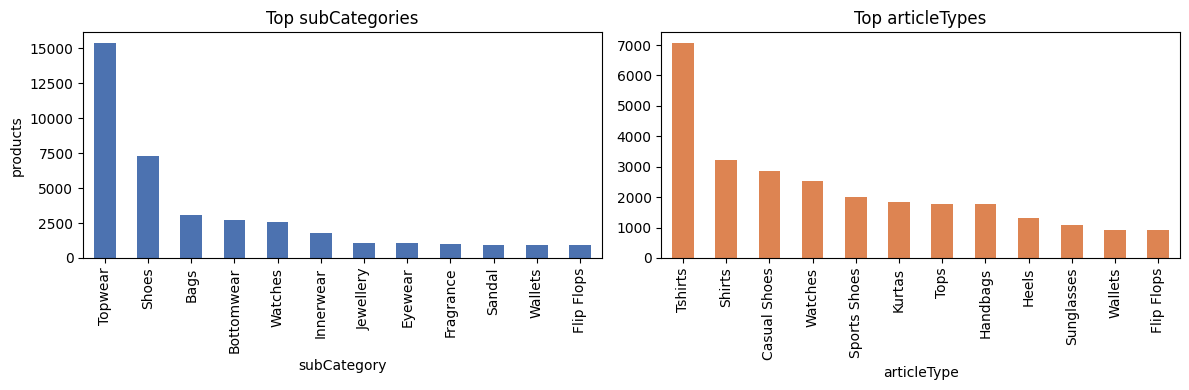

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.subCategory.value_counts().head(12).plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Top subCategories'); axes[0].set_ylabel('products')
df.articleType.value_counts().head(12).plot.bar(ax=axes[1], color='#DD8452')
axes[1].set_title('Top articleTypes')
plt.tight_layout()

In [4]:
# Within one subcategory, popularity always surfaces the same head types:
df[df.subCategory == 'Topwear'].articleType.value_counts().head(5)

articleType
Tshirts        7064
Shirts         3212
Kurtas         1844
Tops           1762
Sweatshirts     285
Name: count, dtype: int64

## 2. The relevance proxy

With no interaction data, relevance is a **content-based proxy** built only from existing columns: an item is relevant to a query when it shares the query's **`articleType` and `gender`**. This is *finer* than the subcategory the baseline groups by — which is what makes the comparison meaningful, and it is reported as a proxy, not as observed user preference.

In [5]:
anchor = int(df[df.subCategory == 'Topwear'].index[0])
rel = relevant_mask(anchor, df)
a = df.loc[anchor]
print(f"Anchor: {a.productDisplayName}  |  {a.articleType} / {a.gender}")
print(f"Proxy-relevant items in catalog: {int(rel.sum()):,}")
df[rel][['productDisplayName', 'articleType', 'gender']].head()

Anchor: Turtle Check Men Navy Blue Shirt  |  Shirts / Men
Proxy-relevant items in catalog: 2,841


,productDisplayName,articleType,gender
6,Fabindia Men Striped Green Shirt,Shirts,Men
15,Reid & Taylor Men Check Purple Shirts,Shirts,Men
29,John Players Men Navy Blue Shirt,Shirts,Men
31,John Players Men Brown Shirt,Shirts,Men
47,John Miller Men Stripes White Red Shirts,Shirts,Men


## 3. Data preparation decisions (`src/data.py`)

The transforms the rest of the project depends on, and why:

- **Resize to 80×80 RGB.** The source photos are ~60×80 (portrait, ~3:4). 80×80 squares them with minimal distortion while staying small enough to train a CNN quickly — the image signal does not need full resolution to predict a coarse subcategory.
- **Drop subcategories with < 100 samples.** 18 long-tail classes (e.g. *Vouchers*, *Home Furnishing*, *Sports Accessories*) have too few examples to learn or evaluate, leaving a **27-subcategory** universe shared by the classifier and the recommender.
- **Drop rows missing a required field** (target or any structured attribute), so every row is fully usable.
- **Fixed `SPLIT_SEED = 42`** for the stratified 70/15/15 split, so model seeds vary the architecture's randomness, never the partition.

In [6]:
vc = df.subCategory.value_counts()
print(f"Subcategories kept: {vc.size}")
print(f"Smallest kept subcategory: {vc.idxmin()} ({vc.min()} products, >= 100)")

Subcategories kept: 27
Smallest kept subcategory: Free Gifts (104 products, >= 100)


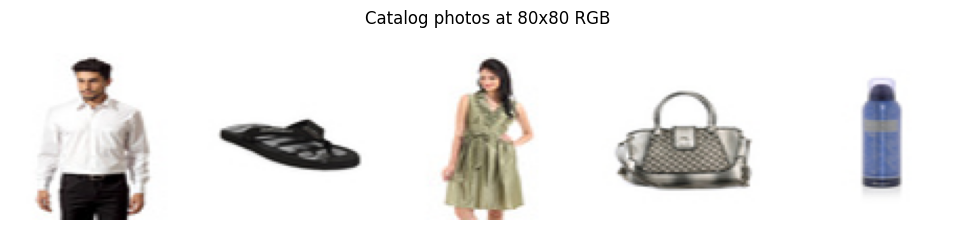

In [7]:
from src.data import IMAGES_CACHE, IMG_SIZE

imgs = np.load(IMAGES_CACHE)
rng = np.random.default_rng(7)
fig, axes = plt.subplots(1, 5, figsize=(10, 2.3))
for ax, i in zip(axes, rng.integers(0, len(imgs), 5)):
    ax.imshow(imgs[i]); ax.axis('off')
fig.suptitle(f'Catalog photos at {IMG_SIZE}x{IMG_SIZE} RGB')
plt.tight_layout()

## Appendix — do the structured attributes predict subcategory?

This is the question the original classification study chased. Cramér's V (association between each attribute and `subCategory`) shows the attributes carry *some* signal but none is strong — which is why, in the appendix experiment, adding them to the photo does **not** beat the image alone, and the recommender takes its category signal from the image-only model.

In [8]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    cm = pd.crosstab(x, y).to_numpy()
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum(); r, k = cm.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

pd.Series(
    {c: round(cramers_v(df[c], df.subCategory), 3) for c in ['gender', 'baseColour', 'season', 'usage']},
    name="Cramer's V vs subCategory",
).sort_values(ascending=False)

season        0.641
gender        0.307
usage         0.278
baseColour    0.223
Name: Cramer's V vs subCategory, dtype: float64